Import of library and dataset

Accuracy clean (best_val_accuracy): 0.375000


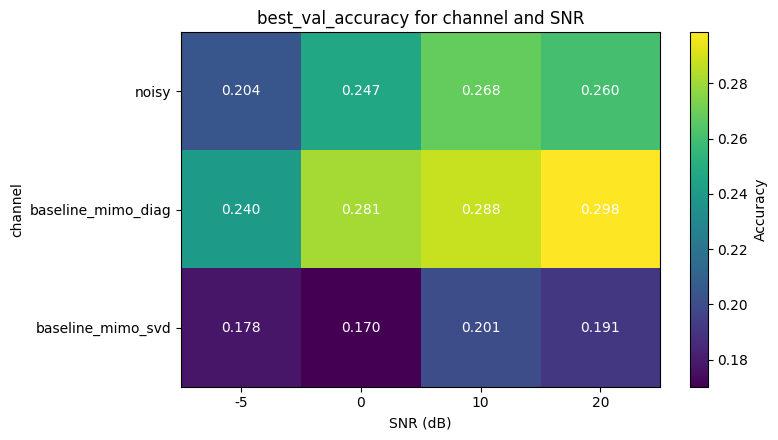

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

# Trova la cartella risultati sia se il notebook e lanciato da root sia da Documents
candidate_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

root = None
for cand in candidate_roots:
    if cand.exists():
        root = cand
        break

accuracy_by_channel = {}
clean_acc = None

for p in root.glob("comm=*/best_training_results.json"):
    channel = p.parent.name.replace("comm=", "")
    data = json.loads(p.read_text(encoding="utf-8"))

    # Prendi SOLO il campo richiesto: best_val_accuracy
    best_val_accuracy = data.get("best_val_accuracy")

    if channel == "clean":
        # Per clean e un valore singolo
        clean_acc = float(best_val_accuracy) if best_val_accuracy is not None else None
        continue

    filtered = {
        float(k): float(v)
        for k, v in best_val_accuracy.items()
        if float(k) != 5.0
    }
    accuracy_by_channel[channel] = filtered


# Ordine richiesto: noisy, diag, svd
desired_order = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]
channels = [c for c in desired_order if c in accuracy_by_channel]

# Stampa esplicita dei risultati richiesti (per canale)
for channel in channels:
    values = {int(k) if k.is_integer() else k: v for k, v in sorted(accuracy_by_channel[channel].items())}

# Costruisci matrice heatmap
snrs = sorted({snr for ch in channels for snr in accuracy_by_channel[ch].keys()})
matrix = [[accuracy_by_channel[ch].get(snr, float("nan")) for snr in snrs] for ch in channels]

fig, ax = plt.subplots(figsize=(8, 3 + 0.5 * len(channels)))
im = ax.imshow(matrix, aspect="auto")
fig.colorbar(im, ax=ax, label="Accuracy")

ax.set_xticks(range(len(snrs)))
ax.set_xticklabels([f"{s:g}" for s in snrs])
ax.set_yticks(range(len(channels)))
ax.set_yticklabels(channels)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("channel")
ax.set_title("best_val_accuracy for channel and SNR")

for i in range(len(channels)):
    for j in range(len(snrs)):
        v = matrix[i][j]
        if v == v:
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white")

plt.tight_layout()


if clean_acc is not None:
    print(f"Accuracy clean (best_val_accuracy): {clean_acc:.6f}")

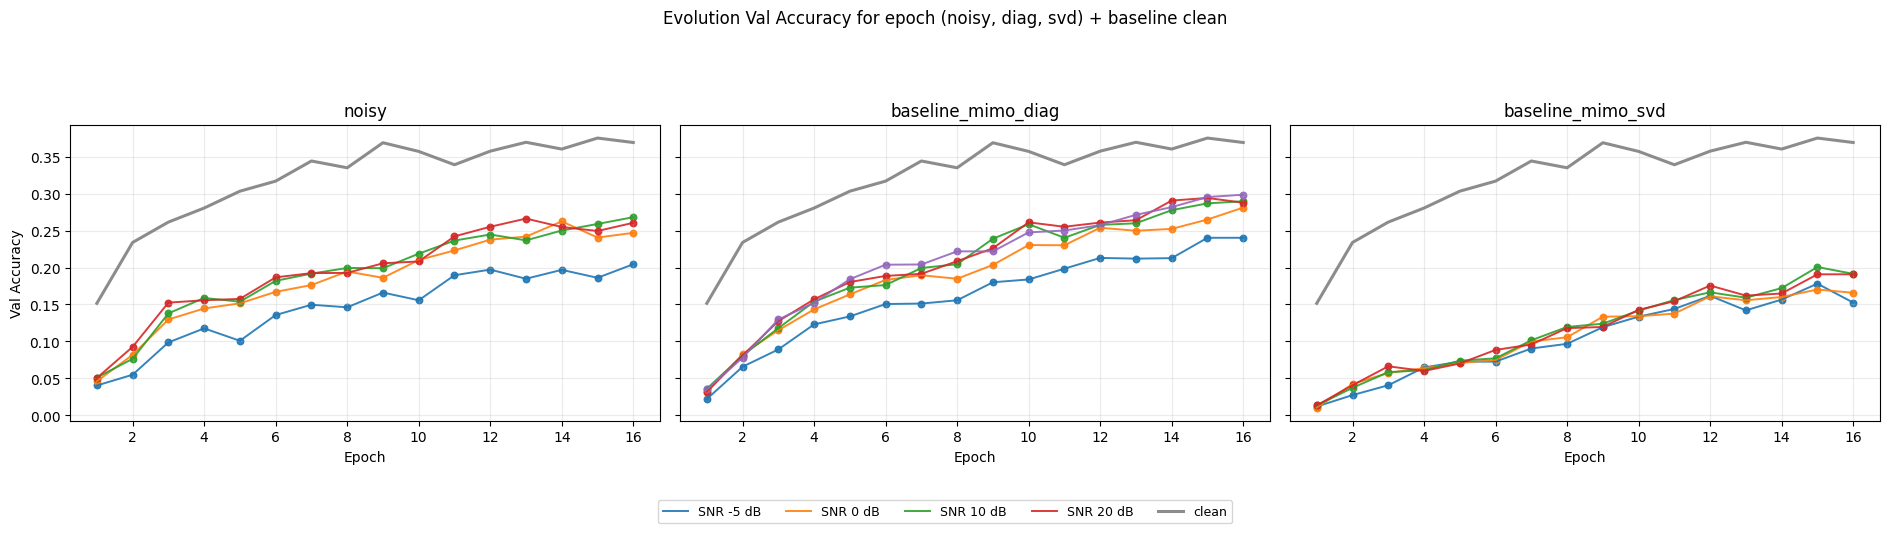

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

# Trova la cartella proposal in modo robusto
candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

channels = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]
channel_to_val_acc = {}

for channel in channels:
    fp = proposal_root / f"comm={channel}" / "final_training_results.json"

    data = json.loads(fp.read_text(encoding="utf-8"))
    val_acc = data.get("Val accuracies")


    channel_to_val_acc[channel] = val_acc

# Serie clean da sovrapporre come retta grigia in ogni subplot
clean_fp = proposal_root / "comm=clean" / "final_training_results.json"

clean_data = json.loads(clean_fp.read_text(encoding="utf-8"))
clean_val_acc = clean_data.get("Val accuracies")

clean_series = [float(v) for v in clean_val_acc]

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharey=True)

for ax, channel in zip(axes, channels):
    val_acc = channel_to_val_acc[channel]
    epochs = list(range(1, len(val_acc) + 1))

    snr_levels = sorted({float(snr) for epoch_dict in val_acc for snr in epoch_dict.keys()})

    for snr in snr_levels:
        key = str(int(snr)) if snr.is_integer() else str(snr)
        y = [float(epoch_dict.get(key, float("nan"))) for epoch_dict in val_acc]

        ax.scatter(epochs, y, s=22, alpha=0.9)
        ax.plot(epochs, y, linewidth=1.4, alpha=0.9, label=f"SNR {snr:g} dB")

    n = min(len(epochs), len(clean_series))
    ax.plot(
        epochs[:n],
        clean_series[:n],
        color="gray",
        linewidth=2.2,
        linestyle="-",
        alpha=0.9,
        label="clean",
    )

    ax.set_title(channel)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)

# Legenda unica condivisa (in basso, fuori dal grafico)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))

axes[0].set_ylabel("Val Accuracy")
fig.suptitle("Evolution Val Accuracy for epoch (noisy, diag, svd) + baseline clean", y=1.02)
plt.tight_layout(rect=[0, 0.08, 1, 0.93])

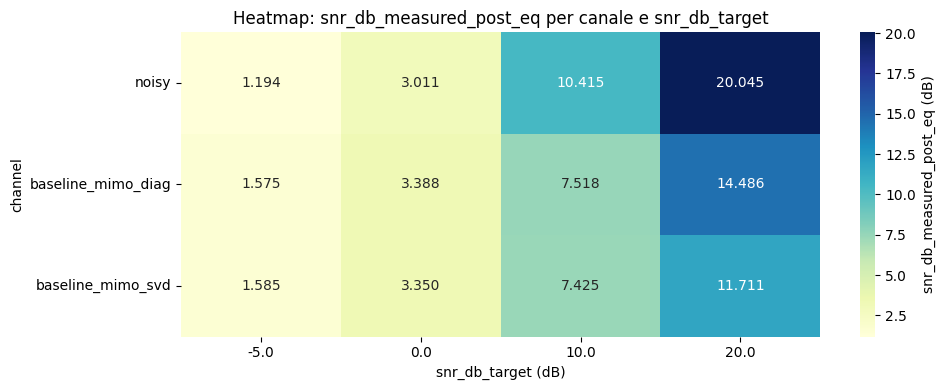

In [4]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

candidate_proposal_roots = [
    Path("results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
    Path("../results/test/cifar100/deit_tiny_patch16_224.fb_in1k/proposal"),
]

proposal_root = None
for cand in candidate_proposal_roots:
    if cand.exists():
        proposal_root = cand
        break

channels = ["noisy", "baseline_mimo_diag", "baseline_mimo_svd"]
rows = []
pattern = re.compile(r"^best_val_snr_db_measured_post_eq_snr_(.+)$")

for channel in channels:
    fp = proposal_root / f"comm={channel}" / "best_training_results.json"

    data = json.loads(fp.read_text(encoding="utf-8"))

    for key, measured_post_eq in data.items():
        match = pattern.match(key)
        if not match:
            continue

        snr_suffix = match.group(1)
        target_key = f"best_val_snr_db_target_snr_{snr_suffix}"
        snr_target = data.get(target_key)

        if snr_target is None:
            continue

        rows.append(
            {
                "channel": channel,
                "snr_db_target": float(snr_target),
                "snr_db_measured_post_eq": float(measured_post_eq),
            }
        )

plot_df = pd.DataFrame(rows)

plot_df = plot_df[plot_df["snr_db_target"] != 5.0]
plot_df = plot_df.sort_values(["channel", "snr_db_target"]).reset_index(drop=True)

# Heatmap: assi = canale e snr target, celle = snr measured post-eq
pivot = plot_df.pivot(index="channel", columns="snr_db_target", values="snr_db_measured_post_eq")
pivot = pivot.reindex(channels)
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

plt.figure(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "snr_db_measured_post_eq (dB)"},
)

plt.title("Heatmap: snr_db_measured_post_eq per canale e snr_db_target")
plt.xlabel("snr_db_target (dB)")
plt.ylabel("channel")
plt.tight_layout()